In [23]:
import spacy
import pandas as pd

In [ ]:

#creating a list of sentences to be preprocessed using Dataframe
data = [
    "When life gives you lemons, make lemonade! 🙂",
    "She bought 2 lemons for $1 at Maven Market.",
    "A dozen lemons will make a gallon of lemonade. [AllRecipes]",
    "lemon, lemon, lemons, lemon, lemon, lemons",
    "He's running to the market to get a lemon — there's a great sale today.",
    "Does Maven Market carry Eureka lemons or Meyer lemons?",
    "An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]",
    "iced tea is my favorite"
]

In [3]:
pd.set_option('display.max_colwidth', None)
data_df = pd.DataFrame(data, columns=['sentence'])
data_df

,sentence
0,"When life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes]
3,"lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]"
7,iced tea is my favorite


In [24]:
# create a test series of sentences for later on
test = [
    "We're going to start this course with traditional NLP applications.",
    "Then we'll move on to modern NLP theory.",
    "Finally, we'll wrap things up with modern NLP applications."
]

test_series = pd.Series(test, name='test')

test_series

0    We're going to start this course with traditional NLP applications.
1                               Then we'll move on to modern NLP theory.
2            Finally, we'll wrap things up with modern NLP applications.
Name: test, dtype: str

In [6]:
phrase = data_df.sentence.iloc[0]
phrase

'When life gives you lemons, make lemonade! 🙂'

In [25]:
def lower_replace_special_char(series):
    output = series.str.lower()
    output = output.str.replace(r'\[.*?\]', '', regex=True)
    output = output.str.replace(r'[^\w\s]', '', regex=True)
    return output

In [26]:
data_df['senetence_clean'] = lower_replace_special_char(data_df['sentence'])

In [27]:
data_df

,sentence,senetence_clean
0,"When life gives you lemons, make lemonade! 🙂",when life gives you lemons make lemonade
1,She bought 2 lemons for $1 at Maven Market.,she bought 2 lemons for 1 at maven market
2,A dozen lemons will make a gallon of lemonade. [AllRecipes],a dozen lemons will make a gallon of lemonade
3,"lemon, lemon, lemons, lemon, lemon, lemons",lemon lemon lemons lemon lemon lemons
4,He's running to the market to get a lemon — there's a great sale today.,hes running to the market to get a lemon theres a great sale today
5,Does Maven Market carry Eureka lemons or Meyer lemons?,does maven market carry eureka lemons or meyer lemons
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]",an arnold palmer is half lemonade half iced tea
7,iced tea is my favorite,iced tea is my favorite


In [ ]:
# Load the spaCy model object. This is a large model that includes vocabulary, syntax, and entities.
nlp = spacy.load("en_core_web_sm")

In [ ]:
# Initialize the spaCy model with the text to be processed. The model will tokenize the text, identify parts of speech, and recognize named entities.
doc = nlp(phrase)
doc

When life gives you lemons, make lemonade! 🙂

In [ ]:
# Tokenization is the process of breaking down a text into smaller units called tokens. Tokens can be words, punctuation marks, or other meaningful elements in the text. Tokenization is an essential step in natural language processing (NLP) because it allows us to analyze and manipulate text data more effectively.
token = [token.text for token in doc]
token

['When', 'life', 'gives', 'you', 'lemons', ',', 'make', 'lemonade', '!', '🙂']

In [17]:
# Lemmatization is the process of reducing a word to its base or root form. This is useful for text preprocessing because it allows us to group together different forms of the same word, which can help improve the accuracy of natural language processing models.
lemma = [token.lemma_ for token in doc]
lemma

['when', 'life', 'give', 'you', 'lemon', ',', 'make', 'lemonade', '!', '🙂']

In [22]:
# Stop words are common words that are often removed from text data during preprocessing because they do not carry significant meaning. Examples of stop words include "the," "is," "in," and "and." Removing stop words can help reduce noise in the data and improve the performance of NLP models.
norm = [token.lemma_ for token in doc if not token.is_stop]
norm

['life', 'give', 'lemon', ',', 'lemonade', '!', '🙂']

In [21]:
joined = " ".join(norm)
joined

'life gives lemons , lemonade ! 🙂'

In [28]:
def token_lemma_stopw_join(text):
    doc = nlp(text)
    norm = [token.lemma_ for token in doc if not token.is_stop]
    output = " ".join(norm)
    return output

In [35]:
data_df['senetence_clean']

0                              when life gives you lemons make lemonade 
1                              she bought 2 lemons for 1 at maven market
2                         a dozen lemons will make a gallon of lemonade 
3                                  lemon lemon lemons lemon lemon lemons
4    hes running to the market to get a lemon  theres a great sale today
5                  does maven market carry eureka lemons or meyer lemons
6                       an arnold palmer is half lemonade half iced tea 
7                                                iced tea is my favorite
Name: senetence_clean, dtype: str

In [34]:
data_df['senetence_clean'].apply(token_lemma_stopw_join)

0                       life give lemon lemonade
1                     buy 2 lemon 1 maven market
2                    dozen lemon gallon lemonade
3            lemon lemon lemon lemon lemon lemon
4        s run market lemon   s great sale today
5    maven market carry eureka lemon meyer lemon
6       arnold palmer half lemonade half ice tea
7                               ice tea favorite
Name: senetence_clean, dtype: str

In [36]:
test_series

0    We're going to start this course with traditional NLP applications.
1                               Then we'll move on to modern NLP theory.
2            Finally, we'll wrap things up with modern NLP applications.
Name: test, dtype: str

In [39]:
lower_replace_special_char(test_series).apply(token_lemma_stopw_join)

0    go start course traditional nlp application
1                              modern nlp theory
2      finally wrap thing modern nlp application
Name: test, dtype: str

In [45]:
# Part of Speech (POS) tagging is the process of assigning a part of speech to each word in a sentence, such as noun, verb, adjective, etc. POS tagging is an important step in natural language processing because it helps us understand the grammatical structure of a sentence and can be used for various NLP tasks such as named entity recognition, sentiment analysis, and machine translation.
data_df.sentence.iloc[0]

'When life gives you lemons, make lemonade! 🙂'

In [52]:
doc2 = nlp(data_df.sentence.iloc[0])
norm = [token.text for token in doc2 if token.pos_ in ['NOUN', 'VERB', 'ADJ']]
" ".join(norm)

'life gives lemons make lemonade 🙂'

In [53]:
def part_of_speech_tagging(text, pos_list = ['NOUN', 'VERB', 'ADJ']):
    doc = nlp(text)
    pos_tags = [token.text for token in doc if token.pos_ in pos_list]
    output = " ".join(pos_tags)
    return output

In [59]:
data_df.senetence_clean

0                              when life gives you lemons make lemonade 
1                              she bought 2 lemons for 1 at maven market
2                         a dozen lemons will make a gallon of lemonade 
3                                  lemon lemon lemons lemon lemon lemons
4    hes running to the market to get a lemon  theres a great sale today
5                  does maven market carry eureka lemons or meyer lemons
6                       an arnold palmer is half lemonade half iced tea 
7                                                iced tea is my favorite
Name: senetence_clean, dtype: str

In [58]:
data_df.senetence_clean.apply(part_of_speech_tagging)

0                life gives lemons make lemonade
1                     bought lemons maven market
2              dozen lemons make gallon lemonade
3          lemon lemon lemons lemon lemon lemons
4    running market get lemon s great sale today
5               market carry lemons meyer lemons
6                arnold palmer lemonade iced tea
7                              iced tea favorite
Name: senetence_clean, dtype: str

# Pipline for text preprocessing using spaCy

In [128]:
def part_of_speech_tagging(text, pos_list = ['NOUN', 'PRON']):
    doc = nlp(text)
    pos_tags = [token.text for token in doc if token.pos_ in pos_list]
    output = " ".join(pos_tags)
    return output

def token_lemma_stopw_join(text):
    doc = nlp(text)
    norm = [token.lemma_ for token in doc if not token.is_stop]
    output = " ".join(norm)
    return output

def lower_replace_special_char(series):
    output = series.str.lower()
    output = output.str.replace(r'\[.*?\]', '', regex=True)
    output = output.str.replace(r'[^\w\s]', '', regex=True)
    return output

def nlp_pipeline(series):
    output = lower_replace_special_char(series)
    output = output.apply(token_lemma_stopw_join)
    output = output.apply(part_of_speech_tagging)
    return output
    


In [129]:
data_df

,sentence,senetence_clean
0,"When life gives you lemons, make lemonade! 🙂",when life gives you lemons make lemonade
1,She bought 2 lemons for $1 at Maven Market.,she bought 2 lemons for 1 at maven market
2,A dozen lemons will make a gallon of lemonade. [AllRecipes],a dozen lemons will make a gallon of lemonade
3,"lemon, lemon, lemons, lemon, lemon, lemons",lemon lemon lemons lemon lemon lemons
4,He's running to the market to get a lemon — there's a great sale today.,hes running to the market to get a lemon theres a great sale today
5,Does Maven Market carry Eureka lemons or Meyer lemons?,does maven market carry eureka lemons or meyer lemons
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]",an arnold palmer is half lemonade half iced tea
7,iced tea is my favorite,iced tea is my favorite


In [130]:
test_series

0    We're going to start this course with traditional NLP applications.
1                               Then we'll move on to modern NLP theory.
2            Finally, we'll wrap things up with modern NLP applications.
Name: test, dtype: str

In [131]:
nlp_pipeline(test_series)

0          nlp application
1               nlp theory
2    thing nlp application
Name: test, dtype: str

In [132]:
cleaned_text = nlp_pipeline(data_df.sentence)
cleaned_text

0                             life lemon
1                     lemon maven market
2                            dozen lemon
3    lemon lemon lemon lemon lemon lemon
4              s market lemon sale today
5                     market lemon lemon
6           palmer lemonade half ice tea
7                       ice tea favorite
Name: sentence, dtype: str

In [133]:
pd.to_pickle(cleaned_text, "cleaned_text.pkl")

In [134]:
pd.read_pickle("cleaned_text.pkl")

0                             life lemon
1                     lemon maven market
2                            dozen lemon
3    lemon lemon lemon lemon lemon lemon
4              s market lemon sale today
5                     market lemon lemon
6           palmer lemonade half ice tea
7                       ice tea favorite
Name: sentence, dtype: str

## Laod my saved pickle file

In [141]:
import pandas as pd

clean_text_df = pd.read_pickle("cleaned_text.pkl")
clean_text_df

0                             life lemon
1                     lemon maven market
2                            dozen lemon
3    lemon lemon lemon lemon lemon lemon
4              s market lemon sale today
5                     market lemon lemon
6           palmer lemonade half ice tea
7                       ice tea favorite
Name: sentence, dtype: str

In [142]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
dtm = cv.fit_transform(clean_text_df)
dtm_df = pd.DataFrame(dtm.toarray(), columns=cv.get_feature_names_out())
dtm_df

,dozen,favorite,half,ice,lemon,lemonade,life,market,maven,palmer,sale,tea,today
0,0,0,0,0,1,0,1,0,0,0,0,0,0
1,0,0,0,0,1,0,0,1,1,0,0,0,0
2,1,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,6,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,1,0,0,1,0,1
5,0,0,0,0,2,0,0,1,0,0,0,0,0
6,0,0,1,1,0,1,0,0,0,1,0,1,0
7,0,1,0,1,0,0,0,0,0,0,0,1,0


In [143]:
cv = CountVectorizer(stop_words='english', ngram_range=(1,2), min_df=.2, max_df=.8)
dtm2 = cv.fit_transform(clean_text_df)
dtm_df2 = pd.DataFrame(dtm2.toarray(), columns=cv.get_feature_names_out())
dtm_df2

,ice,ice tea,lemon,lemon lemon,market,market lemon,tea
0,0,0,1,0,0,0,0
1,0,0,1,0,1,0,0
2,0,0,1,0,0,0,0
3,0,0,6,5,0,0,0
4,0,0,1,0,1,1,0
5,0,0,2,1,1,1,0
6,1,1,0,0,0,0,1
7,1,1,0,0,0,0,1


In [144]:
dtm_freq = dtm_df2.sum().sort_values(ascending=True)
dtm_freq

ice              2
ice tea          2
tea              2
market lemon     2
market           3
lemon lemon      6
lemon           12
dtype: int64

<Axes: >

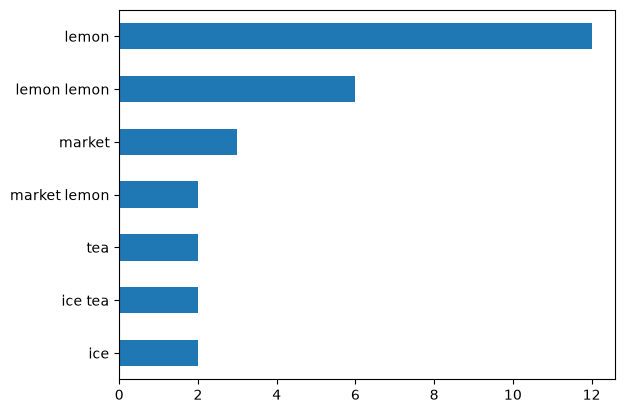

In [145]:
dtm_freq.plot(kind='barh')

# TF-IDF Vectorizer 

In [153]:
from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer()
tfidf = tv.fit_transform(clean_text_df)
tfidf_df = pd.DataFrame(tfidf.toarray(), columns=tv.get_feature_names_out())
tfidf_df


,dozen,favorite,half,ice,lemon,lemonade,life,market,maven,palmer,sale,tea,today
0,0.000000,0.000000,0.000000,0.000000,0.447007,0.000000,0.894531,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.375318,0.000000,0.000000,0.543168,0.75107,0.000000,0.000000,0.000000,0.000000
2,0.894531,0.000000,0.000000,0.000000,0.447007,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.300100,0.000000,0.000000,0.434311,0.00000,0.000000,0.600547,0.000000,0.600547
5,0.000000,0.000000,0.000000,0.000000,0.810145,0.000000,0.000000,0.586230,0.00000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.476474,0.399323,0.000000,0.476474,0.000000,0.000000,0.00000,0.476474,0.000000,0.399323,0.000000
7,0.000000,0.644859,0.000000,0.540443,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.540443,0.000000


In [183]:
tv = TfidfVectorizer(stop_words='english', min_df=.1, max_df=.5)
tfidf2 = tv.fit_transform(clean_text_df)
tfidf_df2 = pd.DataFrame(tfidf2.toarray(), columns=tv.get_feature_names_out())
tfidf_df2

,dozen,favorite,half,ice,lemonade,life,market,maven,palmer,sale,tea,today
0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.586007,0.810306,0.000000,0.000000,0.000000,0.000000
2,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.455297,0.000000,0.000000,0.629565,0.000000,0.629565
5,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.0,0.000000,0.476474,0.399323,0.476474,0.0,0.000000,0.000000,0.476474,0.000000,0.399323,0.000000
7,0.0,0.644859,0.000000,0.540443,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.540443,0.000000


In [184]:
tfidf_df2 = tfidf_df2.sum().sort_values(ascending=True)
tfidf_df2

half        0.476474
lemonade    0.476474
palmer      0.476474
sale        0.629565
today       0.629565
favorite    0.644859
maven       0.810306
ice         0.939765
tea         0.939765
dozen       1.000000
life        1.000000
market      2.041304
dtype: float64

<Axes: title={'center': 'Least 10 Most Frequent Terms'}, xlabel='Frequency', ylabel='Terms'>

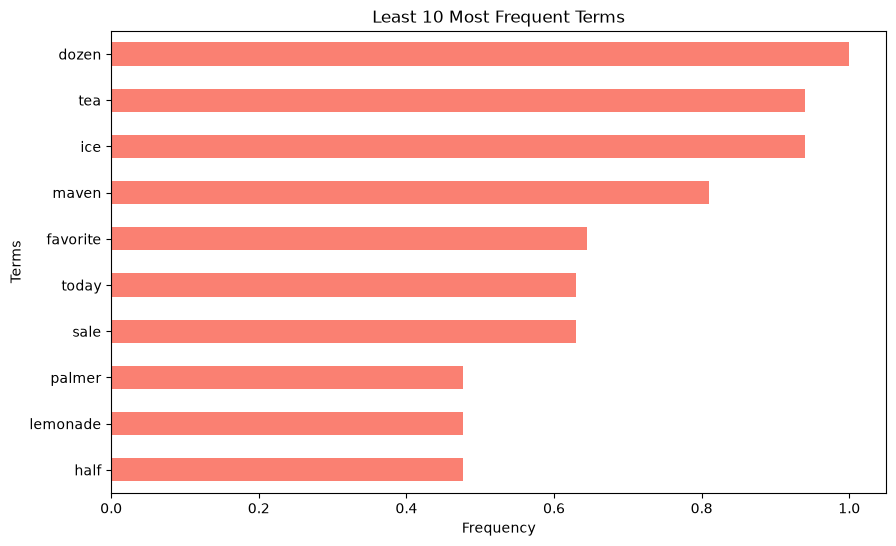

In [186]:
tfidf_df2.head(10).plot(kind="barh", title='Least 10 Most Frequent Terms',xlabel='Frequency', ylabel='Terms', color='salmon', figsize=(10,6) )